# IMPORTS

In [1]:
import sys
sys.path.append("../src")

from data_loader import load_data, convert_to_datetime_index
from data_cleaning import (
    enforce_monthly_frequency,
    handle_missing_values,
    detect_and_treat_outliers
)
from eda import plot_time_series, seasonal_decomposition_plot, adf_test
from feature_engineering import (
    create_lag_features,
    create_rolling_features,
    create_date_features,
    drop_na_rows,
    create_target
)

from config import TARGET_COLUMN, DATE_COLUMN

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading 

In [2]:
df = load_data()

df.head()

,date,avg_monthly_price
0,2005-01-01,5500
1,2005-02-01,5476
2,2005-03-01,5466
3,2005-04-01,5487
4,2005-05-01,5876


In [3]:
df = convert_to_datetime_index(df, DATE_COLUMN)
df.head()

,avg_monthly_price
date,
2005-01-01,5500
2005-02-01,5476
2005-03-01,5466
2005-04-01,5487
2005-05-01,5876


In [4]:
df = enforce_monthly_frequency(df)
df.head()

,avg_monthly_price
date,
2005-01-01,5500
2005-02-01,5476
2005-03-01,5466
2005-04-01,5487
2005-05-01,5876


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
avg_monthly_price,249.0,7918.891566,2804.992684,3500.0,6123.0,7250.0,9783.0,16163.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 249 entries, 2005-01-01 to 2025-09-01
Freq: MS
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   avg_monthly_price  249 non-null    int64
dtypes: int64(1)
memory usage: 3.9 KB


# Data Cleaning and EDA

In [7]:
# Checking if all the dates are there or not
start_date = df.index.min()
end_date = df.index.max()
start_date, end_date

(Timestamp('2005-01-01 00:00:00'), Timestamp('2025-09-01 00:00:00'))

In [8]:
full_date_range = pd.date_range(start=start_date, end=end_date, freq='MS')
present_dates = pd.Index(df.index)
missing_dates = full_date_range.difference(present_dates)

print("Missing dates found:", missing_dates)

Missing dates found: DatetimeIndex([], dtype='datetime64[ns]', freq='MS')


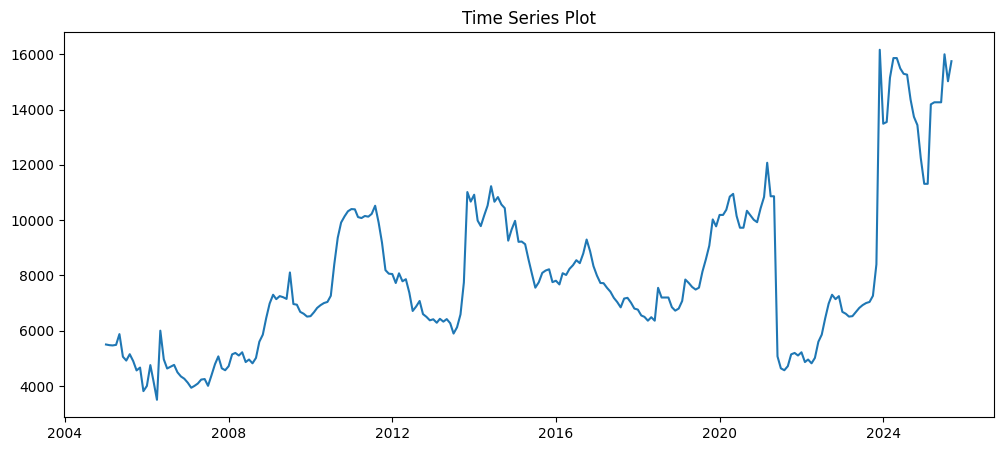

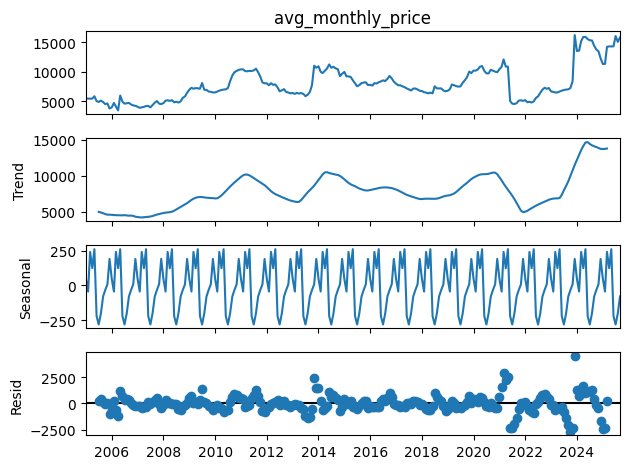

ADF Statistic: -1.6310679104992172
p-value: 0.46693177566134453
Series is NOT stationary


In [9]:
plot_time_series(df, TARGET_COLUMN)
seasonal_decomposition_plot(df, TARGET_COLUMN)
adf_test(df[TARGET_COLUMN])

# Feature Engineering

In [10]:
df = create_lag_features(df, TARGET_COLUMN)
df = create_rolling_features(df, TARGET_COLUMN)
df = create_date_features(df)

df = drop_na_rows(df)

df.head()

,avg_monthly_price,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12,month,year,quarter
date,,,,,,,,,,,,,,
2006-01-01,4000,3813.0,4562.0,4919.0,5500.0,4159.333333,447.790502,4514.666667,516.168448,4947.500000,615.745446,1,2006,1
2006-02-01,4755,4000.0,4665.0,5149.0,5476.0,4189.333333,498.724707,4449.000000,438.556268,4887.416667,594.290327,2,2006,1
2006-03-01,4176,4755.0,3813.0,4899.0,5466.0,4310.333333,395.019409,4328.500000,386.410533,4779.916667,596.784636,3,2006,1
2006-04-01,3500,4176.0,4000.0,4562.0,5487.0,4143.666667,628.124457,4151.500000,487.951125,4614.333333,655.527315,4,2006,2
2006-05-01,6000,3500.0,4755.0,4665.0,5876.0,4558.666667,1293.184184,4374.000000,899.634815,4624.666667,677.821689,5,2006,2


# Fix Stationarity & Variance

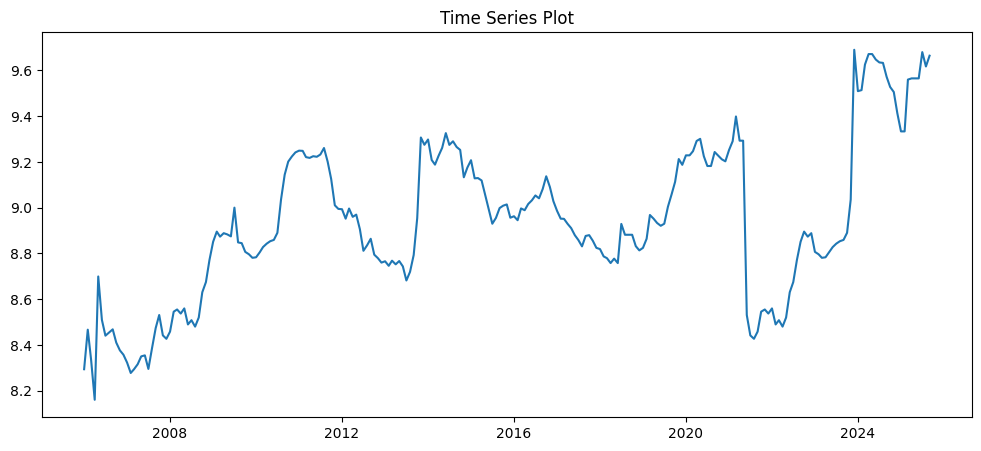

ADF Statistic: -2.231290631467341
p-value: 0.19508536109967273
Series is NOT stationary


In [11]:
df["Price_log"] = np.log(df["avg_monthly_price"])

plot_time_series(df, "Price_log")
adf_test(df["Price_log"])

In [12]:
df["Price_log_diff"] = df["Price_log"].diff()

adf_test(df["Price_log_diff"].dropna())

ADF Statistic: -15.290192456944565
p-value: 4.454033746940184e-28
Series is stationary


In [13]:
df = create_target(df, TARGET_COLUMN, use_log=True)
df.head()

,avg_monthly_price,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12,month,year,quarter,Price_log,Price_log_diff,target
date,,,,,,,,,,,,,,,,,
2006-01-01,4000,3813.0,4562.0,4919.0,5500.0,4159.333333,447.790502,4514.666667,516.168448,4947.500000,615.745446,1,2006,1,8.294050,NaN,8.294050
2006-02-01,4755,4000.0,4665.0,5149.0,5476.0,4189.333333,498.724707,4449.000000,438.556268,4887.416667,594.290327,2,2006,1,8.466952,0.172902,8.466952
2006-03-01,4176,4755.0,3813.0,4899.0,5466.0,4310.333333,395.019409,4328.500000,386.410533,4779.916667,596.784636,3,2006,1,8.337109,-0.129843,8.337109
2006-04-01,3500,4176.0,4000.0,4562.0,5487.0,4143.666667,628.124457,4151.500000,487.951125,4614.333333,655.527315,4,2006,2,8.160518,-0.176591,8.160518
2006-05-01,6000,3500.0,4755.0,4665.0,5876.0,4558.666667,1293.184184,4374.000000,899.634815,4624.666667,677.821689,5,2006,2,8.699515,0.538997,8.699515


In [14]:
print("Total Rows:", len(df))

Total Rows: 237


In [15]:
adf_test(df["Price_log_diff"].dropna())

ADF Statistic: -15.290192456944565
p-value: 4.454033746940184e-28
Series is stationary


# Model Selection, Training, Prediction And Evalution

## SARIMAX Model:

In [16]:
from src.models.sarima_model import SarimaModel
from config import TEST_HORIZON

In [17]:
# Train-Test split
train = df.iloc[:-TEST_HORIZON]
test = df.iloc[-TEST_HORIZON:]

In [18]:
#Training the SARIMA Model
model = SarimaModel(order=(1,1,1),
                    seasonal_order=(1,1,1,12))

model.train(train["Price_log"])

In [19]:
# Making the Prediction

forecast, conf_int = model.forecast(TEST_HORIZON)

In [20]:
# Evaluating the Predictions
metrics = model.evaluate(test["Price_log"], forecast)
metrics

{'MAE': 0.09794046426189107,
 'RMSE': np.float64(0.124767081448438),
 'MAPE': np.float64(1.0342398354151072)}

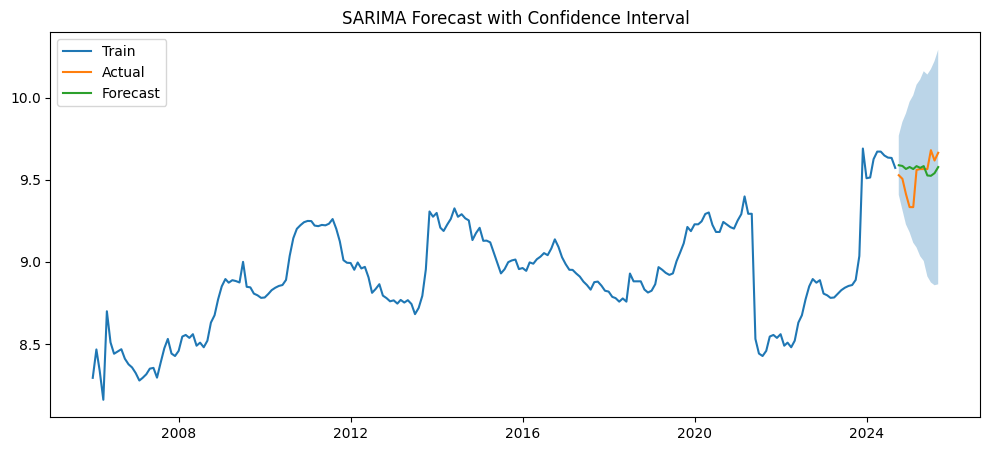

In [21]:
# SARIMAX Prediction Plot

plt.figure(figsize=(12,5))

plt.plot(train.index, train["Price_log"], label="Train")
plt.plot(test.index, test["Price_log"], label="Actual")
plt.plot(test.index, forecast, label="Forecast")

plt.fill_between(test.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 alpha=0.3)

plt.legend()
plt.title("SARIMA Forecast with Confidence Interval")
plt.show()

In [22]:
forecast_actual = np.exp(forecast)
test_actual = np.exp(test["Price_log"])

metrics = model.evaluate(test_actual, forecast_actual)
metrics

{'MAE': 1336.3103190288725,
 'RMSE': np.float64(1666.2989891323089),
 'MAPE': np.float64(10.29708779955072)}

Residual Mean: 0.010773046527792884
Residual Std: 0.6723910494271199


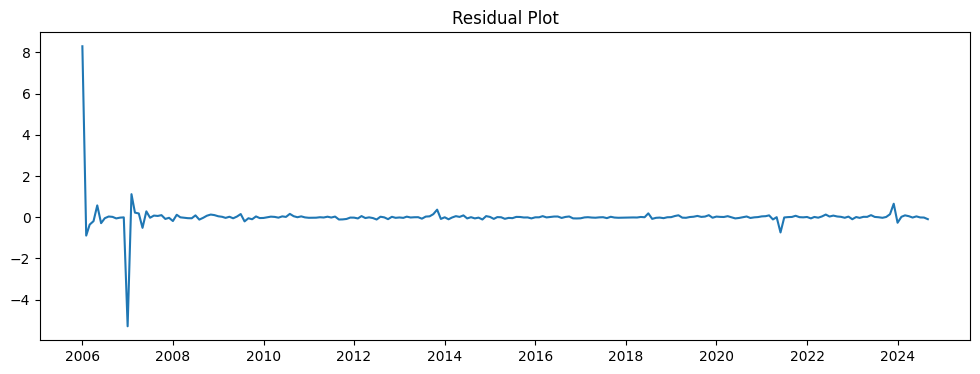

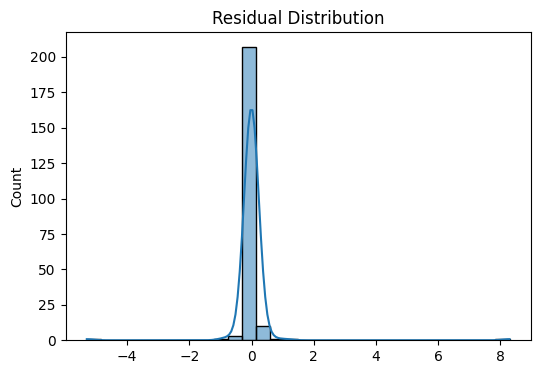

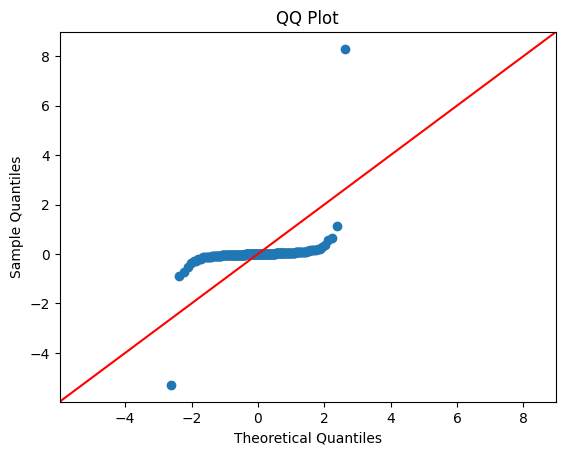

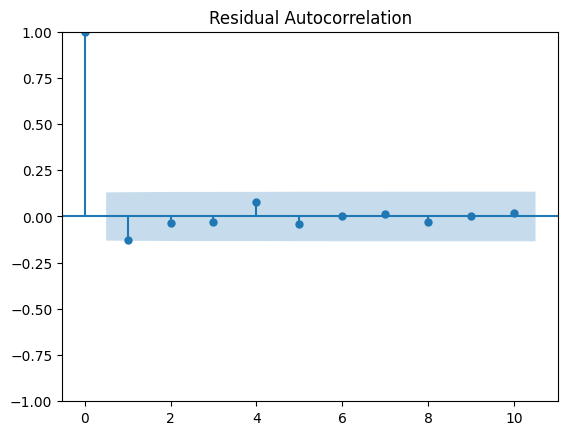


Ljung-Box Test:
     lb_stat  lb_pvalue
10  6.436555    0.77735


date
2006-01-01    8.294050
2006-02-01   -0.893024
2006-03-01   -0.360531
2006-04-01   -0.193428
2006-05-01    0.571177
                ...   
2024-05-01   -0.018404
2024-06-01    0.037784
2024-07-01   -0.013384
2024-08-01   -0.018673
2024-09-01   -0.097376
Freq: MS, Length: 225, dtype: float64

In [23]:
import sys
sys.path.append("../src")

from residuals import residual_diagnostics

train_residuals = model.fitted_model.resid
residual_diagnostics(train_residuals, np.zeros(len(train_residuals)))

## Prophet Model:

In [24]:
# import sys
# sys.path.append("../models")

from src.models.prophet_model import ProphetModel
from config import TEST_HORIZON

Importing plotly failed. Interactive plots will not work.


In [25]:
# Prepare data
prophet_df = df.reset_index()[["date", "Price_log"]]
prophet_df.columns = ["ds", "y"]

# Train-test split
train_df = prophet_df.iloc[:-TEST_HORIZON]
test_df = prophet_df.iloc[-TEST_HORIZON:]

In [26]:
# Training the Prophet Model

model = ProphetModel(changepoint_prior_scale=0.1)

model.train(train_df)

22:47:52 - cmdstanpy - INFO - Chain [1] start processing
22:47:52 - cmdstanpy - INFO - Chain [1] done processing


In [27]:
# Predicting results on Test Data

forecast = model.forecast(periods=TEST_HORIZON)
# Get only forecast horizon
forecast_test = forecast.tail(TEST_HORIZON)

In [28]:
# Convert back to actual price scale
y_pred_actual = np.exp(forecast_test["yhat"])
y_true_actual = np.exp(test_df["y"])

metrics = model.evaluate(y_true_actual, y_pred_actual)
metrics

{'MAE': 3656.8059476884323,
 'RMSE': np.float64(3896.358404519674),
 'MAPE': np.float64(25.70696172364292)}

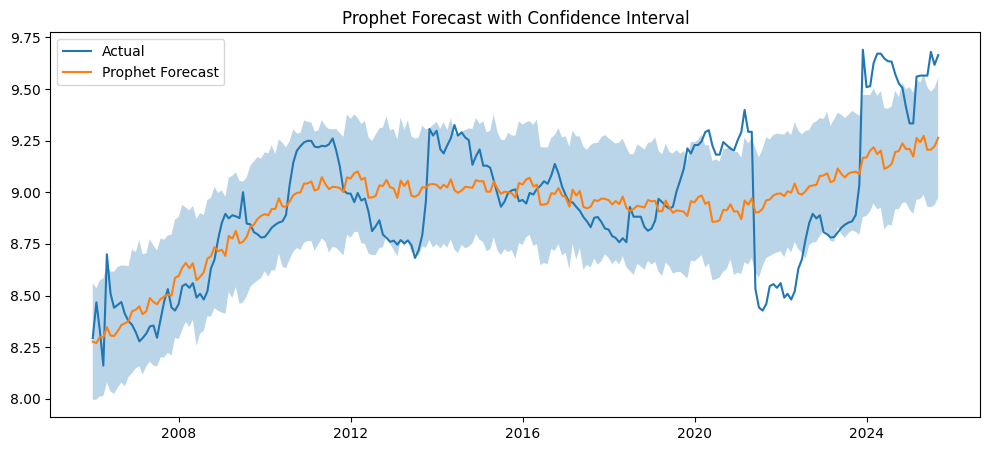

In [29]:
# Plotting Prophet models prediction

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df.index, df["Price_log"], label="Actual")
plt.plot(forecast["ds"], forecast["yhat"], label="Prophet Forecast")

plt.fill_between(
    forecast["ds"],
    forecast["yhat_lower"],
    forecast["yhat_upper"],
    alpha=0.3
)

plt.legend()
plt.title("Prophet Forecast with Confidence Interval")
plt.show()

In [30]:
df.columns

Index(['avg_monthly_price', 'lag_1', 'lag_3', 'lag_6', 'lag_12',
       'rolling_mean_3', 'rolling_std_3', 'rolling_mean_6', 'rolling_std_6',
       'rolling_mean_12', 'rolling_std_12', 'month', 'year', 'quarter',
       'Price_log', 'Price_log_diff', 'target'],
      dtype='object')

In [31]:
# Fine-tuning Prophet

from itertools import product

param_grid = {
    "changepoint_prior_scale": [0.01, 0.1, 0.5, 1],
    "seasonality_prior_scale": [5, 10, 20],
    "changepoint_range": [0.8, 0.9, 0.95]
}

results = []

for cps, sps, cpr in product(
    param_grid["changepoint_prior_scale"],
    param_grid["seasonality_prior_scale"],
    param_grid["changepoint_range"]
):

    model = ProphetModel(
        changepoint_prior_scale=cps,
        seasonality_prior_scale=sps,
        changepoint_range=cpr
    )

    model.train(train_df)
    forecast = model.forecast(TEST_HORIZON)

    forecast_test = forecast.tail(TEST_HORIZON)

    y_pred = np.exp(forecast_test["yhat"])
    y_true = np.exp(test_df["y"])

    metrics = model.evaluate(y_true, y_pred)

    results.append({
        "cps": cps,
        "sps": sps,
        "cpr": cpr,
        "MAPE": metrics["MAPE"]
    })

results_df = pd.DataFrame(results).sort_values("MAPE")
results_df.head()

22:47:52 - cmdstanpy - INFO - Chain [1] start processing
22:47:52 - cmdstanpy - INFO - Chain [1] done processing
22:47:52 - cmdstanpy - INFO - Chain [1] start processing
22:47:52 - cmdstanpy - INFO - Chain [1] done processing
22:47:53 - cmdstanpy - INFO - Chain [1] start processing
22:47:53 - cmdstanpy - INFO - Chain [1] done processing
22:47:53 - cmdstanpy - INFO - Chain [1] start processing
22:47:53 - cmdstanpy - INFO - Chain [1] done processing
22:47:53 - cmdstanpy - INFO - Chain [1] start processing
22:47:53 - cmdstanpy - INFO - Chain [1] done processing
22:47:53 - cmdstanpy - INFO - Chain [1] start processing
22:47:53 - cmdstanpy - INFO - Chain [1] done processing
22:47:53 - cmdstanpy - INFO - Chain [1] start processing
22:47:53 - cmdstanpy - INFO - Chain [1] done processing
22:47:54 - cmdstanpy - INFO - Chain [1] start processing
22:47:54 - cmdstanpy - INFO - Chain [1] done processing
22:47:54 - cmdstanpy - INFO - Chain [1] start processing
22:47:54 - cmdstanpy - INFO - Chain [1]

,cps,sps,cpr,MAPE
33,1.0,20,0.8,12.952486
30,1.0,10,0.8,12.990393
27,1.0,5,0.8,13.060626
21,0.5,10,0.8,14.319977
24,0.5,20,0.8,14.385655


## XGBoost Model:

In [32]:
from src.models.xgboost_model import XGBoostModel
from config import TEST_HORIZON

In [33]:
# Define feature columns
feature_cols = [
    "lag_1","lag_3","lag_6","lag_12",
    "rolling_mean_3","rolling_std_3",
    "rolling_mean_6","rolling_std_6",
    "rolling_mean_12","rolling_std_12",
    "month","quarter"
]

In [34]:
# Train-Test Split 
X = df[feature_cols]
y = df["target"]

train_X = X.iloc[:-TEST_HORIZON]
test_X = X.iloc[-TEST_HORIZON:]

train_y = y.iloc[:-TEST_HORIZON]
test_y = y.iloc[-TEST_HORIZON:]

In [35]:
# Training Model
model = XGBoostModel()

model.train(train_X, train_y)

In [36]:
# Predicting on test set
pred_log = model.predict(test_X)
pred_log

array([9.300304 , 9.251633 , 9.217731 , 9.20914  , 9.22534  , 9.204872 ,
       9.289069 , 9.315256 , 9.257935 , 9.236577 , 9.2220335, 9.228159 ],
      dtype=float32)

In [37]:
# convert back
pred_actual = np.exp(pred_log)
true_actual = np.exp(test_y)

metrics = model.evaluate(true_actual, pred_actual)
metrics

{'MAE': 3442.1947428385447,
 'RMSE': np.float64(3728.6059454088704),
 'MAPE': np.float64(24.088876568491024)}

In [38]:
def recursive_forecast_xgb(model, df_train, feature_cols, horizon=12):

    df_temp = df_train.copy()
    predictions = []

    for step in range(horizon):

        # Take last row features
        X_last = df_temp[feature_cols].iloc[-1:].copy()

        # Predict next log price
        pred_log = model.predict(X_last)[0]

        predictions.append(pred_log)

        # Create new row
        next_date = df_temp.index[-1] + pd.DateOffset(months=1)

        new_row = pd.DataFrame(index=[next_date])

        # Update target
        new_row["target"] = pred_log

        # Update lag features
        for lag in [1,3,6,12]:
            if lag == 1:
                new_row[f"lag_{lag}"] = pred_log
            else:
                new_row[f"lag_{lag}"] = df_temp["target"].iloc[-lag]

        # Recompute rolling features
        temp_series = pd.concat([df_temp["target"], pd.Series([pred_log], index=[next_date])])

        for window in [3,6,12]:
            new_row[f"rolling_mean_{window}"] = temp_series.iloc[-window:].mean()
            new_row[f"rolling_std_{window}"] = temp_series.iloc[-window:].std()

        # Date features
        new_row["month"] = next_date.month
        new_row["quarter"] = (next_date.month - 1) // 3 + 1

        # Append
        df_temp = pd.concat([df_temp, new_row])

    return predictions

In [39]:
train_df = df.iloc[:-12].copy()

feature_cols = [
    "lag_1","lag_3","lag_6","lag_12",
    "rolling_mean_3","rolling_std_3",
    "rolling_mean_6","rolling_std_6",
    "rolling_mean_12","rolling_std_12",
    "month","quarter"
]

In [40]:
pred_log = recursive_forecast_xgb(model.model, train_df, feature_cols, 12)

In [41]:
pred_actual = np.exp(pred_log)
true_actual = np.exp(df["target"].iloc[-12:])

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(true_actual, pred_actual)
rmse = np.sqrt(mean_squared_error(true_actual, pred_actual))
mape = np.mean(np.abs((true_actual - pred_actual) / true_actual)) * 100

print({"MAE": mae, "RMSE": rmse, "MAPE": mape})

{'MAE': 8306.079305013021, 'RMSE': np.float64(8738.761065670555), 'MAPE': np.float64(59.668669493607986)}


# Evaluation and Final Model Selection

We tested out 3 models(SARIMA, Prophet, and XGBoost)
The best mode was the SARIMA model as it has the lowest MAPE score which is 10% and might capture seasonality change then other models. It strugles to understand the sudden spike in 2023 but it stil performs better than the rest of the models. 

## Fine-Tuning SARMIA

## Grid Search

In [43]:
import itertools
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import numpy as np

In [45]:
# Parameter grid
p = [0,1,2]
q = [0,1,2]
P = [0,1]
Q = [0,1]

d = 1
D = 1
s = 12

results = []
train_series = train["Price_log"]

In [46]:
for param in itertools.product(p, q, P, Q):
    
    order = (param[0], d, param[1])
    seasonal_order = (param[2], D, param[3], s)
    
    try:
        model = SARIMAX(train_series,
                        order=order,
                        seasonal_order=seasonal_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        
        fitted = model.fit(disp=False)
        
        results.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": fitted.aic
        })
        
    except:
        continue

results_df = pd.DataFrame(results).sort_values("AIC")
results_df.head()

,order,seasonal_order,AIC
3,"(0, 1, 0)","(1, 1, 1, 12)",-356.104338
15,"(1, 1, 0)","(1, 1, 1, 12)",-356.022497
7,"(0, 1, 1)","(1, 1, 1, 12)",-353.447981
27,"(2, 1, 0)","(1, 1, 1, 12)",-352.787723
19,"(1, 1, 1)","(1, 1, 1, 12)",-352.172790


In [47]:
# Selecting the Top by AIC Statistics

top_models = results_df.head(3)
top_models

,order,seasonal_order,AIC
3,"(0, 1, 0)","(1, 1, 1, 12)",-356.104338
15,"(1, 1, 0)","(1, 1, 1, 12)",-356.022497
7,"(0, 1, 1)","(1, 1, 1, 12)",-353.447981


In [48]:
# Evaluating the The top 3 models on Test
best_results = []

for _, row in top_models.iterrows():
    
    order = row["order"]
    seasonal_order = row["seasonal_order"]
    
    model = SARIMAX(train_series,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    
    fitted = model.fit(disp=False)
    
    forecast = fitted.get_forecast(steps=12)
    pred_log = forecast.predicted_mean
    
    pred_actual = np.exp(pred_log)
    true_actual = np.exp(test["Price_log"])
    
    mae = np.mean(np.abs(true_actual - pred_actual))
    rmse = np.sqrt(np.mean((true_actual - pred_actual)**2))
    mape = np.mean(np.abs((true_actual - pred_actual)/true_actual))*100
    
    best_results.append({
        "order": order,
        "seasonal_order": seasonal_order,
        "MAPE": mape,
        "RMSE": rmse
    })

pd.DataFrame(best_results).sort_values("MAPE")

,order,seasonal_order,MAPE,RMSE
2,"(0, 1, 1)","(1, 1, 1, 12)",10.425089,1679.642247
1,"(1, 1, 0)","(1, 1, 1, 12)",10.431046,1680.027949
0,"(0, 1, 0)","(1, 1, 1, 12)",10.499700,1688.021920


# Training Final Model on Full Data

In [49]:
final_model = SARIMAX(
    df["Price_log"],
    order=(0,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fitted = final_model.fit(disp=False)

# Forecast Next 12 Months

In [50]:
forecast = final_fitted.get_forecast(steps=12)

pred_log = forecast.predicted_mean
conf_int = forecast.conf_int()

pred_actual = np.exp(pred_log)
lower_actual = np.exp(conf_int.iloc[:,0])
upper_actual = np.exp(conf_int.iloc[:,1])

In [52]:
import joblib
joblib.dump(final_fitted, "../src/models/sarima_final.pkl")

['../src/models/sarima_final.pkl']

In [2]:
# Testing The SARIMA Inference Class

from src.pipeline.sarima_inference import SarimaInference

In [4]:
inference = SarimaInference("../src/models/sarima_final.pkl")
inference.load_model()

result = inference.forecast(steps=12)
result

{'predictions': [16232.66648592496,
  16421.80848500498,
  17033.11010459306,
  17025.712677817533,
  16840.223941425986,
  17181.29773821424,
  17066.258683979668,
  17245.94056575462,
  16309.933440356075,
  16217.250630621373,
  16488.57113715489,
  16981.161302150434],
 'lower_confidence': [13566.892810743733,
  12592.985986520887,
  12247.97601381994,
  11602.749806405087,
  10950.12096603632,
  10709.189140919829,
  10232.516227464486,
  9973.929252048392,
  9118.780481551725,
  8781.65397233706,
  8661.34566428771,
  8664.996633948722],
 'upper_confidence': [19422.2409595957,
  21414.761694075863,
  23687.73742762291,
  24983.292497402337,
  25898.63100846007,
  27564.831294389754,
  28463.886984783403,
  29819.989542883286,
  29172.094817615165,
  29948.711124904108,
  31389.230805785595,
  33278.701810440645]}